In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
dataset = pd.read_csv('IEA Global EV Data 2024 new.csv')
dataset.head()

,region,category,parameter,mode,powertrain,year,unit,value,percentage
0,Austria,Historical,EV stock,Cars,BEV,2010,Vehicles,350,"35000,00%"
1,Austria,Historical,EV stock share,Cars,EV,2010,percent,789.999.961.853,"78999996185300,00%"
2,Belgium,Historical,EV stock,Buses,BEV,2010,Vehicles,3,"300,00%"
3,Belgium,Historical,EV sales,Vans,BEV,2010,Vehicles,7,"700,00%"
4,Belgium,Historical,EV stock,Vans,BEV,2010,Vehicles,62,"6200,00%"


In [45]:
dataset.sample(5)

,region,category,parameter,mode,powertrain,year,unit,value,percentage
5207,Germany,Historical,EV sales,Trucks,BEV,2019,Vehicles,620,"62000,00%"
1369,India,Historical,EV stock share,Cars,EV,2013,percent,12.000.000.104.308,"1200000010430800,00%"
10121,Finland,Historical,EV sales share,Trucks,EV,2023,percent,189.999.997.615.814,"18999999761581400,00%"
7575,India,Projection-STEPS,EV sales share,Cars,EV,2021,percent,349.999.994.039.536,"34999999403953600,00%"
10684,Spain,Historical,EV stock share,Vans,EV,2023,percent,680.000.007.152.557,"68000000715255700,00%"


In [46]:
dataset.tail()

,region,category,parameter,mode,powertrain,year,unit,value,percentage
12649,World,Projection-STEPS,EV sales share,Cars,EV,2035,percent,55,"5500,00%"
12650,World,Projection-STEPS,EV stock share,Cars,EV,2035,percent,31,"3100,00%"
12651,World,Projection-APS,EV charging points,EV,Publicly available fast,2035,charging points,9400000,"940000000,00%"
12652,World,Projection-APS,EV charging points,EV,Publicly available slow,2035,charging points,15000000,"1500000000,00%"
12653,World,Projection-STEPS,EV stock share,Trucks,EV,2035,percent,9,"900,00%"


In [47]:
dataset.shape

(12654, 9)

In [48]:
dataset.columns

Index(['region', 'category', 'parameter', 'mode', 'powertrain', 'year', 'unit',
       'value', 'percentage'],
      dtype='object')

In [49]:
dataset['value'].head(17)

0                    350
1        789.999.961.853
2                      3
3                      7
4                     62
5                     48
6                     61
7                      8
8      9.999.999.776.483
9                      1
10                     9
11                     2
12    18.999.999.389.052
13    13.000.000.268.221
14    10.999.999.940.395
15     1.300.000.003.539
16     1.300.000.003.539
Name: value, dtype: object

In [ ]:
dataset['value'] = (
    dataset['value']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)

)

In [51]:
dataset['value'] = pd.to_numeric(dataset['value'], errors= 'coerce')
dataset['value'] = dataset['value'].astype(int)

In [52]:
dataset['value'].head(17)

0                350
1       789999961853
2                  3
3                  7
4                 62
5                 48
6                 61
7                  8
8      9999999776483
9                  1
10                 9
11                 2
12    18999999389052
13    13000000268221
14    10999999940395
15     1300000003539
16     1300000003539
Name: value, dtype: int64

In [53]:
dataset['percentage']

0                 35000,00%
1        78999996185300,00%
2                   300,00%
3                   700,00%
4                  6200,00%
                ...        
12649              5500,00%
12650              3100,00%
12651         940000000,00%
12652        1500000000,00%
12653               900,00%
Name: percentage, Length: 12654, dtype: object

In [54]:
# Dropping percentage is better because it is inconsistent, corrupted, and redundant.
dataset= dataset.drop(columns=['percentage'])

In [55]:
dataset.columns

Index(['region', 'category', 'parameter', 'mode', 'powertrain', 'year', 'unit',
       'value'],
      dtype='object')

In [56]:
dataset.head()

,region,category,parameter,mode,powertrain,year,unit,value
0,Austria,Historical,EV stock,Cars,BEV,2010,Vehicles,350
1,Austria,Historical,EV stock share,Cars,EV,2010,percent,789999961853
2,Belgium,Historical,EV stock,Buses,BEV,2010,Vehicles,3
3,Belgium,Historical,EV sales,Vans,BEV,2010,Vehicles,7
4,Belgium,Historical,EV stock,Vans,BEV,2010,Vehicles,62


In [57]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12654 entries, 0 to 12653
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   region      12654 non-null  object
 1   category    12654 non-null  object
 2   parameter   12654 non-null  object
 3   mode        12654 non-null  object
 4   powertrain  12654 non-null  object
 5   year        12654 non-null  int64 
 6   unit        12654 non-null  object
 7   value       12654 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 791.0+ KB


In [58]:
dataset.describe()

,year,value
count,12654.000000,1.265400e+04
mean,2019.822112,5.557510e+13
std,5.476494,1.591110e+14
min,2010.000000,1.000000e+00
25%,2016.000000,1.400000e+02
50%,2020.000000,6.000000e+03
75%,2022.000000,3.500000e+10
max,2035.000000,9.900000e+14


In [59]:
dataset.describe(include= 'object')

,region,category,parameter,mode,powertrain,unit
count,12654,12654,12654,12654,12654,12654
unique,54,3,8,5,6,6
top,World,Historical,EV stock,Cars,EV,Vehicles
freq,1250,9174,3470,4706,4894,6842


In [60]:
print(f' The unique values of region are:{dataset['region'].unique()}')

 The unique values of region are:['Austria' 'Belgium' 'Brazil' 'Canada' 'China' 'Denmark' 'EU27' 'Europe'
 'France' 'Germany' 'Iceland' 'India' 'Israel' 'Italy' 'Japan' 'Korea'
 'Netherlands' 'New Zealand' 'Norway' 'Poland' 'Portugal'
 'Rest of the world' 'Spain' 'Sweden' 'United Kingdom' 'USA' 'World'
 'Australia' 'Chile' 'Finland' 'Mexico' 'Switzerland' 'Turkiye' 'Greece'
 'South Africa' 'Bulgaria' 'Colombia' 'Costa Rica' 'Czech Republic'
 'Estonia' 'Hungary' 'Ireland' 'Latvia' 'Lithuania' 'Romania' 'Seychelles'
 'Slovakia' 'Slovenia' 'Thailand' 'United Arab Emirates' 'Croatia'
 'Cyprus' 'Luxembourg' 'Indonesia']


In [61]:
print(f' The unique categories are:{dataset['category'].unique()}')

 The unique categories are:['Historical' 'Projection-STEPS' 'Projection-APS']


In [62]:
print(f' The unique parameters are:{dataset['parameter'].unique()}')

 The unique parameters are:['EV stock' 'EV stock share' 'EV sales' 'EV sales share'
 'Electricity demand' 'Oil displacement Mbd'
 'Oil displacement, million lge' 'EV charging points']


In [63]:
print(f' The unique modes are:{dataset['mode'].unique()}')

 The unique modes are:['Cars' 'Buses' 'Vans' 'Trucks' 'EV']


In [64]:
print(f' The unique powertrains are:{dataset['powertrain'].unique()}')

 The unique powertrains are:['BEV' 'EV' 'PHEV' 'FCEV' 'Publicly available slow'
 'Publicly available fast']


In [65]:
print(f' The unique years are:{dataset['year'].unique()}')

 The unique years are:[2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023
 2025 2030 2035]


In [66]:
print(f' The unique units are:{dataset['unit'].unique()}')

 The unique units are:['Vehicles' 'percent' 'GWh' 'Milion barrels per day'
 'Oil displacement, million lge' 'charging points']


In [67]:
dataset.isnull().sum()

region        0
category      0
parameter     0
mode          0
powertrain    0
year          0
unit          0
value         0
dtype: int64

In [68]:
dataset.duplicated().sum()

np.int64(0)

In [69]:
dataset.head()

,region,category,parameter,mode,powertrain,year,unit,value
0,Austria,Historical,EV stock,Cars,BEV,2010,Vehicles,350
1,Austria,Historical,EV stock share,Cars,EV,2010,percent,789999961853
2,Belgium,Historical,EV stock,Buses,BEV,2010,Vehicles,3
3,Belgium,Historical,EV sales,Vans,BEV,2010,Vehicles,7
4,Belgium,Historical,EV stock,Vans,BEV,2010,Vehicles,62


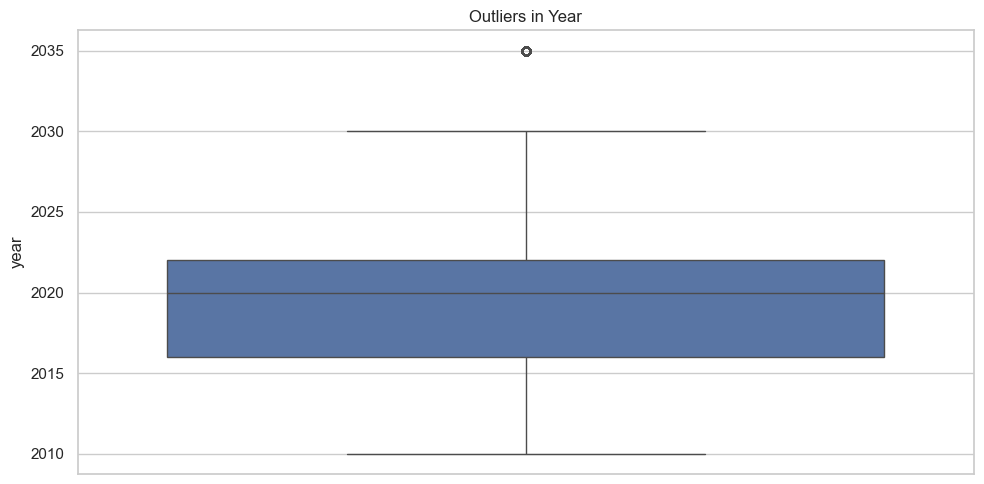

In [70]:
plt.figure(figsize= (10, 5))
sns.boxplot(dataset['year'])
plt.title('Outliers in Year')

plt.tight_layout()
plt.show()

In [71]:
Q1 = dataset['year'].quantile(0.25)
Q3 = dataset['year'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

dataset_no_year_outliers = dataset[
    (dataset['year'] >= lower_bound) &
    (dataset['year'] <= upper_bound)
]

print("Original shape:", dataset.shape)
print("After removing year outliers:", dataset_no_year_outliers.shape)

Original shape: (12654, 8)
After removing year outliers: (12105, 8)


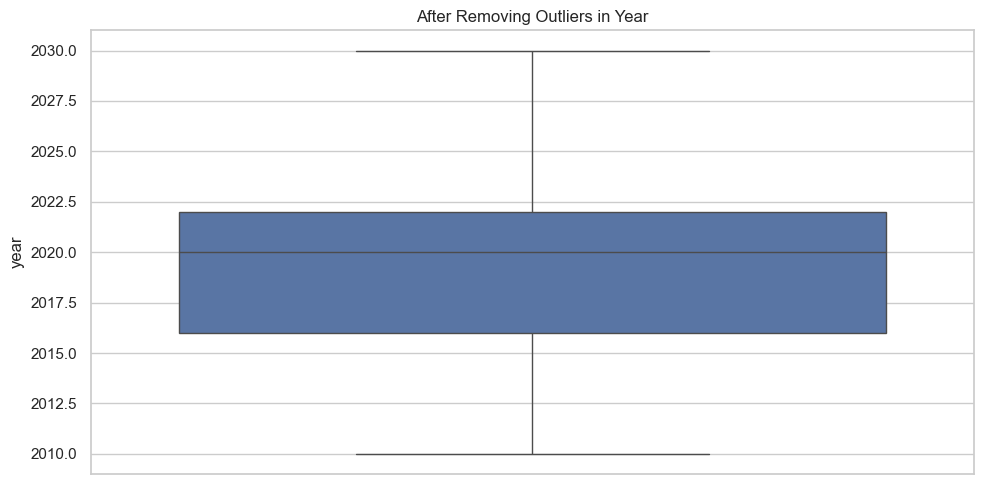

In [72]:
plt.figure(figsize= (10, 5))
sns.boxplot(dataset_no_year_outliers['year'])
plt.title('After Removing Outliers in Year')

plt.tight_layout()
plt.show()

In [73]:
max_sales = dataset['region'].value_counts()
print(max_sales)

region
World                   1250
Europe                  1234
China                   1138
Rest of the world        954
USA                      737
India                    702
EU27                     424
Netherlands              358
France                   358
United Kingdom           345
Denmark                  319
Belgium                  310
Germany                  298
Norway                   270
Sweden                   269
Japan                    260
Spain                    245
Switzerland              245
Canada                   240
Italy                    230
Korea                    209
Finland                  200
Poland                   194
Portugal                 189
New Zealand              185
Brazil                   183
Israel                   148
Austria                  116
Iceland                  115
Chile                    103
Australia                 94
Mexico                    87
Greece                    83
South Africa              83
Turkiye

In [74]:
max_sales_year = dataset['year'].value_counts()
print(max_sales_year)

year
2023    1348
2021    1342
2022    1336
2020    1282
2019     797
2018     761
2017     720
2016     668
2015     621
2030     550
2025     549
2035     549
2014     515
2013     481
2012     442
2011     390
2010     303
Name: count, dtype: int64


In [75]:
max_sales_modes = dataset['mode'].value_counts()
print(max_sales_modes)

mode
Cars      4706
Buses     2696
Vans      2568
Trucks    1766
EV         918
Name: count, dtype: int64


In [76]:
highest_sales = dataset['value'].max()
print(highest_sales)
highest_sales_row = dataset[dataset['value']==highest_sales]
print(highest_sales_row)

990000009536743
        region    category       parameter  mode powertrain  year     unit  \
3375       USA  Historical  EV sales share  Cars         EV  2016  percent   
6521  Portugal  Historical  EV sales share  Vans         EV  2020  percent   

                value  
3375  990000009536743  
6521  990000009536743  


In [77]:
ev_data = dataset[dataset['parameter'].isin(['EV stock', 'EV sales'])]
yearly_adoption = (
    ev_data
    .groupby('year')['value']
    .sum()
    .reset_index()
)

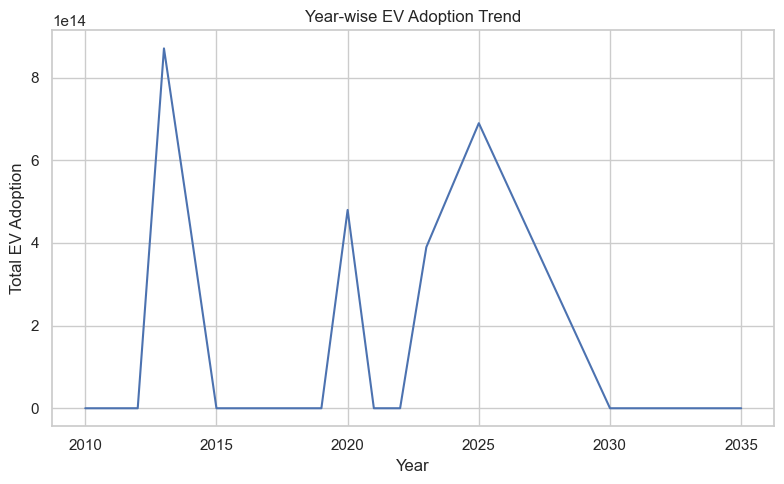

In [78]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=yearly_adoption, x='year', y='value')
plt.title("Year-wise EV Adoption Trend")
plt.xlabel("Year")
plt.ylabel("Total EV Adoption")
plt.tight_layout()
plt.show()

mode
Cars      2975
Buses     1485
Vans      1449
Trucks     933
Name: count, dtype: int64

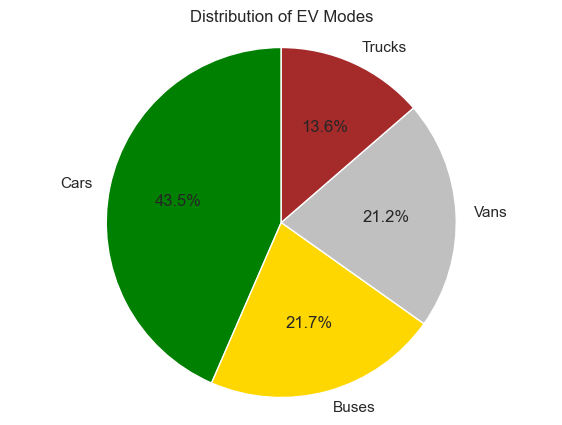

In [79]:
vehicles = dataset.loc[dataset['unit']=='Vehicles']

mode = vehicles['mode'].value_counts()
display(mode)

import matplotlib.pyplot as plt

# Data for the pie chart
mode_counts = vehicles['mode'].value_counts()
colors= ['green', 'gold', 'silver', 'brown']

# Plotting the pie chart
plt.figure(figsize=(7, 5))
plt.pie(mode_counts, labels=mode_counts.index, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Distribution of EV Modes')
plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
plt.show()

In [ ]:
# # Group the data by region and calculate the sum of the 'value' column
vehicles_countries_grouped = vehicles.groupby('region')['value'].sum()

# Convert the Series to a DataFrame
vehicles_countries_df = pd.DataFrame(vehicles_countries_grouped).reset_index()

# Rename the columns for clarity
vehicles_countries_df.columns = ['region', 'total_value']

# Drop the row where the region is 'World'
vehicles_countries_df = vehicles_countries_df[vehicles_countries_df['region'] != 'World']

# Display the DataFrame after dropping the row
print(vehicles_countries_df)

                  region      total_value
0              Australia           578832
1                Austria           871966
2                Belgium          1687010
3                 Brazil           264947
4               Bulgaria             4623
5                 Canada  480000021489921
6                  Chile            14458
7                  China       1148051600
8               Colombia            16023
9             Costa Rica            27631
10               Croatia             7557
11                Cyprus             2260
12        Czech Republic            34300
13               Denmark          1102561
14                  EU27         33242559
15               Estonia             4585
16                Europe        593775414
17               Finland           742723
18                France          6787772
19               Germany         10201107
20                Greece           105356
21               Hungary            42035
22               Iceland          

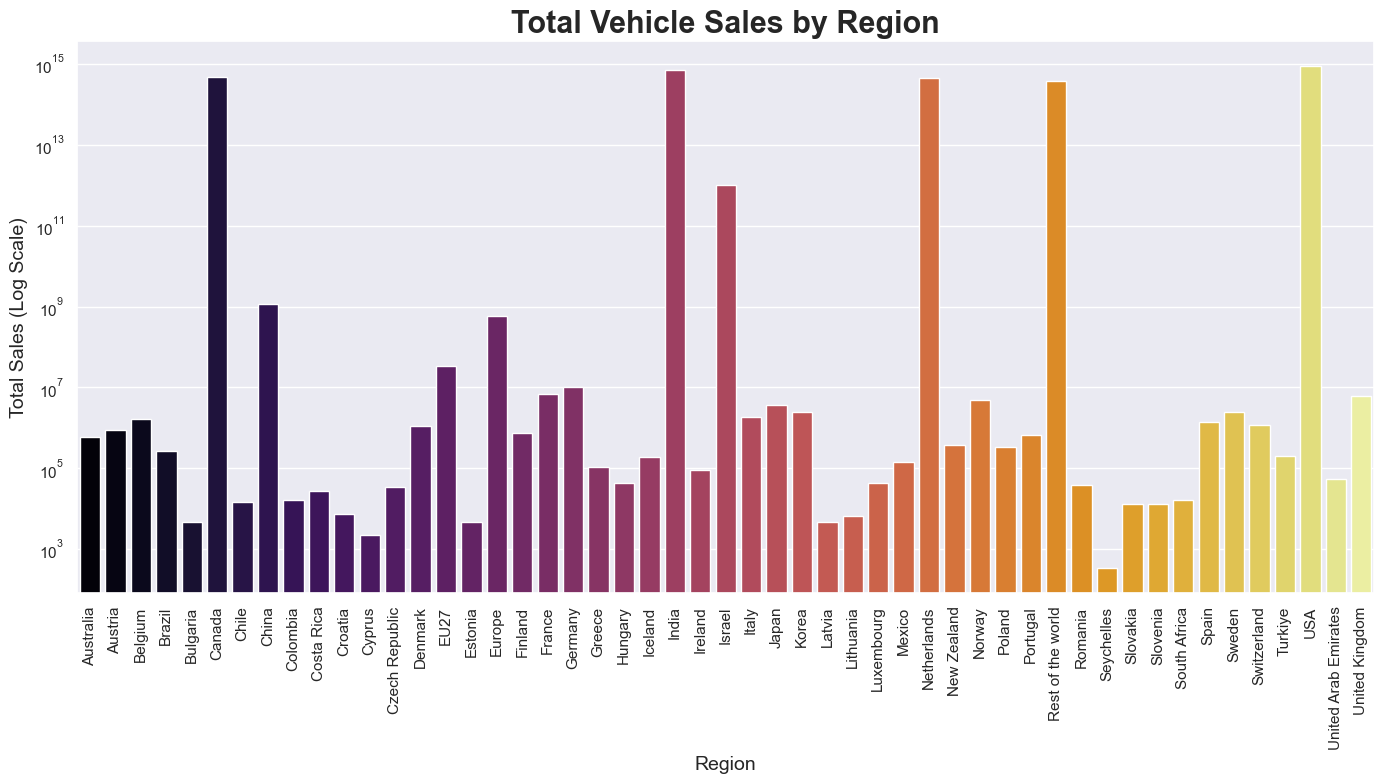

In [113]:
# Ignore FutureWarning
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Set plot style
sns.set_style(style="darkgrid")

# Create the figure and axis
plt.figure(figsize=(14, 8))

# Plot a bar chart
sns.barplot(data=vehicles_countries_df, x='region', y='total_value', palette="inferno")

# Customize the plot
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.title('Total Vehicle Sales by Region', fontsize=22, fontweight='bold')
plt.xlabel('Region', fontsize=14)
plt.ylabel('Total Sales (Log Scale)', fontsize=14)

# Use logarithmic scale for the y-axis if values span a large range
plt.yscale('log')

# Show the plot
plt.tight_layout()
plt.show()